## Árboles de Decisión en Machine Learning
###### Elizabeth Vega Pacheco
###### Ariana Belinda Pulido Solano
###### Juan Gerardo Reyes Carrera
###### Hugo Martínez Vallejo

### 1. Carga de librerías.
Aquí incorporaremos las librerías necesarias.

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Dataset de ejemplo y utilidades de sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Visualización
import matplotlib.pyplot as plt

%matplotlib inline

### 2. Carga del dataset
Usaremos el dataset del Iris, este dataset es muy usado en la comunidad de machine learning...

In [2]:
iris = load_iris()

# Convertimos a DataFrame para visualizarlo mejor
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['especie'] = iris.target
df['especie'] = df['especie'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Distribución de clases
df['especie'].value_counts()

especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### 3. Preprocesamiento

Pasos básicos antes de entrenar:
- Verificar valores nulos
- Separar variables predictoras (X) y variable objetivo (y)
- Dividir en conjunto de entrenamiento y prueba

In [4]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum()) #Datos nulos = true:1 #Datos reales = false:0

Valores nulos por columna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
especie              0
dtype: int64


In [5]:
# Variables predictoras (X) y variable objetivo (y)
X = df[iris.feature_names]
y = df['especie']

# División train/test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (120, 4)
Prueba: (30, 4)


### 4. Entrenamiento del algoritmo

Creamos y entrenamos un DecisionTreeClassifier. Limitamos la profundidad máxima (max_depth)
para evitar sobreajuste y facilitar la visualización del árbol.


In [6]:
modelo = DecisionTreeClassifier(
    criterion='gini',   # criterio de división
    max_depth=3,         # profundidad máxima del árbol
    random_state=42
)

modelo.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

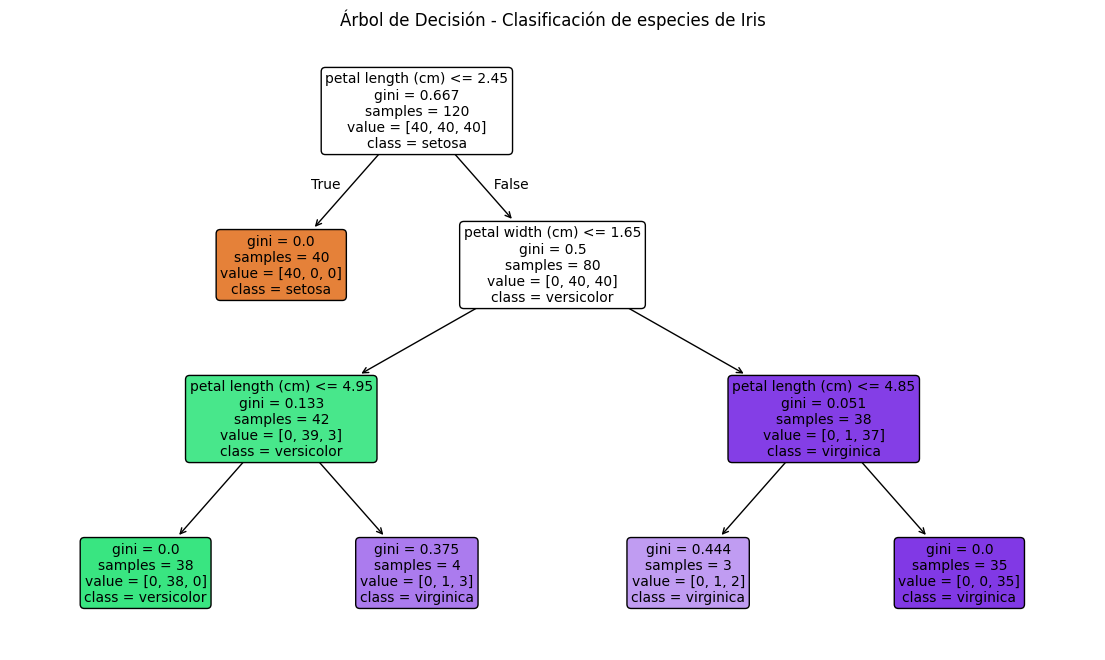

In [7]:
# Visualización del árbol entrenado
plt.figure(figsize=(14, 8))
plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Clasificación de especies de Iris")
plt.show()


### 5. Evaluación del algoritmo

Evaluamos el desempeño del modelo sobre el conjunto de prueba usando:
- **Accuracy** (exactitud)
- **Reporte de clasificación** (precisión, recall, f1-score)
- **Matriz de confusión**


In [8]:
y_pred = modelo.predict(X_test)

exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy): {exactitud:.2%}") ##Muliplica x100 y anade con 2 decimales


Exactitud (Accuracy): 96.67%


In [9]:
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Reporte de clasificación:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



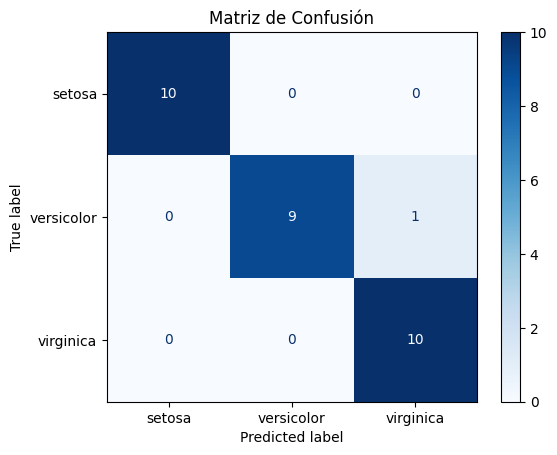

In [10]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()


### Conclusión

El árbol de decisión clasifica las flores usando reglas simples tipo *"si el ancho del pétalo es
menor a X, entonces..."*. Su principal ventaja es que el modelo resultante es **interpretable**:
se puede leer el árbol como un diagrama de flujo de decisiones, lo cual es ideal para explicar el
algoritmo en una presentación.
